# **Retina Based ML Project**

This project aims to use the "DNA Methylation Data - Epigenetic Biomarkers" dataset provided on Kaggle by Juan Schafle. The goal is to build an end-to-end machine learning pipeline that classifies the DNA methylation status (Methylated vs. Unmethylated) of CpG sites. By analyzing features like CpG density and evolutionary conservation scores, this analysis explores how epigenetic patterns can serve as early detection biomarkers for rare genetic disorders like Retinitis Pigmentosa.

In [1]:
# Loading Data
!pip install kagglehub -q
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("juanschafle/dna-methylation-data-epigenetic-biomarkers")
print("Data downloaded successfully to:", path)
df = pd.read_csv(f"{path}/full_dataset.csv")
df.head()

100%|██████████| 69.7k/69.7k [00:00<00:00, 40.0MB/s]

Extracting files...
Data downloaded successfully to: /root/.cache/kagglehub/datasets/juanschafle/dna-methylation-data-epigenetic-biomarkers/versions/1


,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
0,0.799343,0.949839,0.297447,0.268438,1
1,0.672347,0.831158,0.456644,0.477923,1
2,0.829538,0.614908,0.262274,0.567279,0
3,1.000000,0.438266,0.407612,1.000000,1
4,0.653169,0.774556,0.000000,0.761311,0


# Visualization Of The Data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

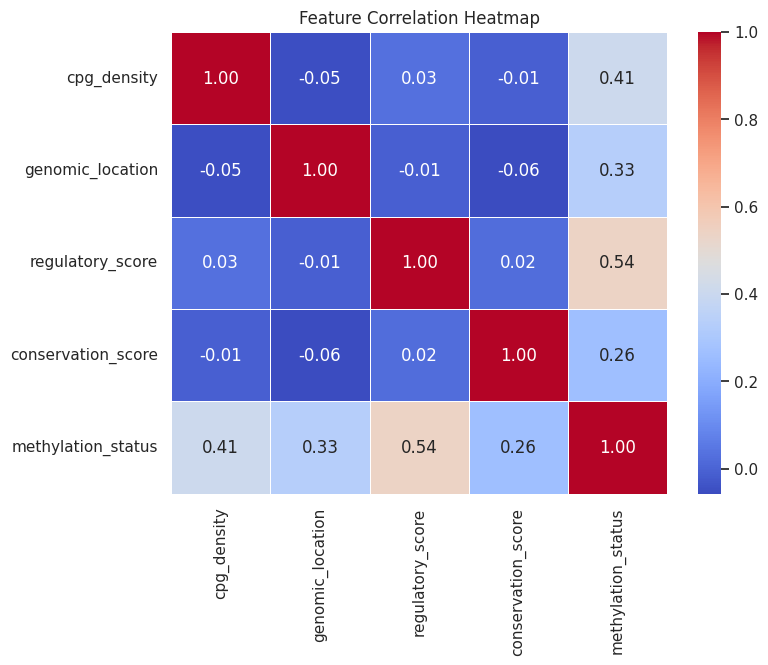

In [3]:
sns.set_theme(style="whitegrid")
#Correlation Heathmap
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
print("\n" + "="*50 + "\n")

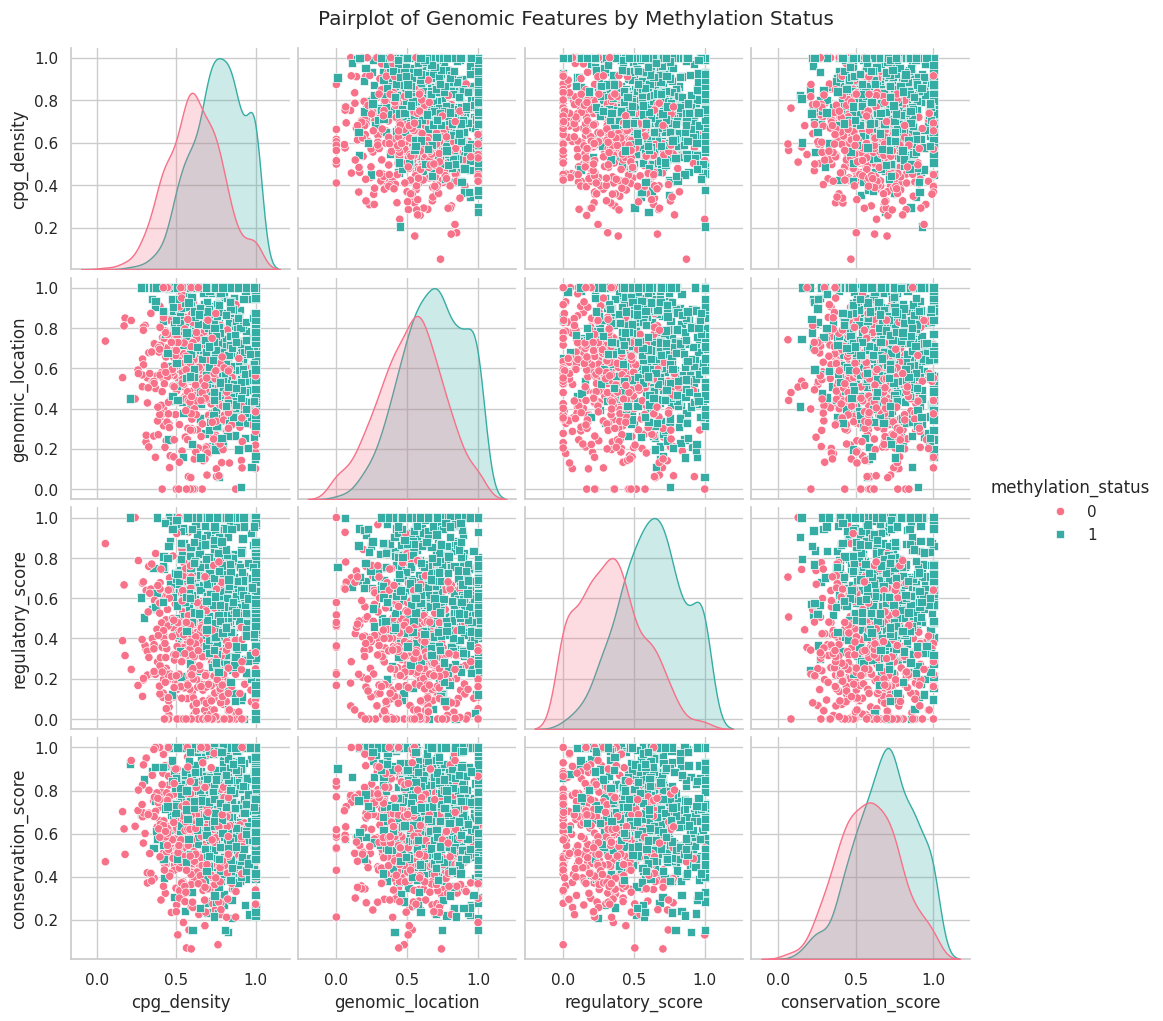

In [4]:
#Scatter Matrix)
sns.pairplot(df, hue="methylation_status", palette="husl", markers=["o", "s"])
plt.suptitle("Pairplot of Genomic Features by Methylation Status", y=1.02)
plt.show()

/tmp/ipykernel_12230/2492856181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="methylation_status", y="regulatory_score", palette="muted")


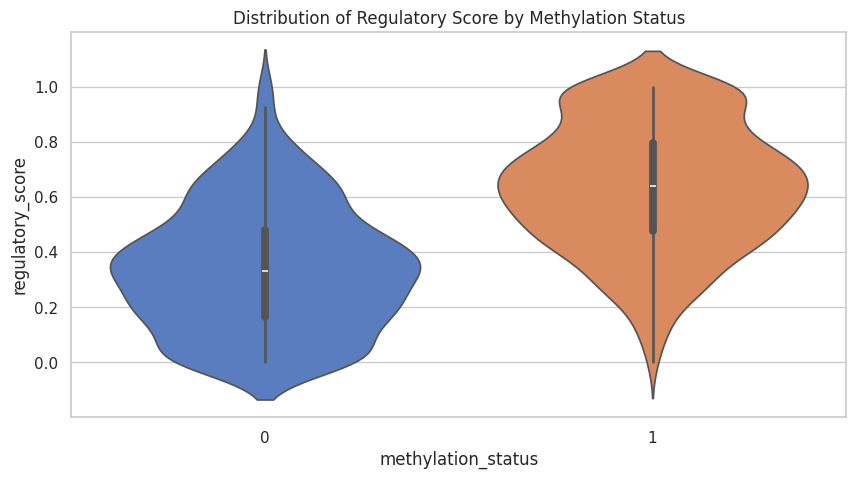

In [5]:
# Violin Plot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="methylation_status", y="regulatory_score", palette="muted")
plt.title("Distribution of Regulatory Score by Methylation Status")
plt.show()
print("\n" + "="*50 + "\n")

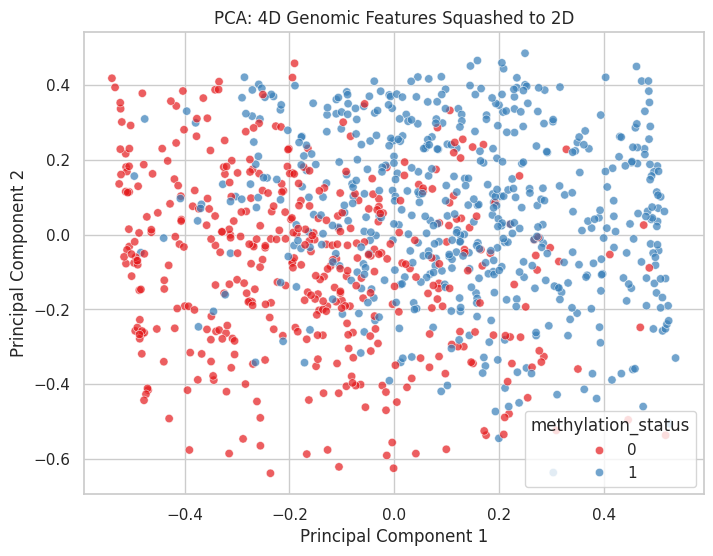

In [6]:
# PCA
X = df.drop("methylation_status", axis=1)
y = df["methylation_status"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="Set1", alpha=0.7)
plt.title("PCA: 4D Genomic Features Squashed to 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Model And Evaluation

In [7]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Training on 800 sample, Testing on 200 sample...

Model Accuracy: 91.50%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        93
           1       0.93      0.91      0.92       107

    accuracy                           0.92       200
   macro avg       0.91      0.92      0.91       200
weighted avg       0.92      0.92      0.92       200



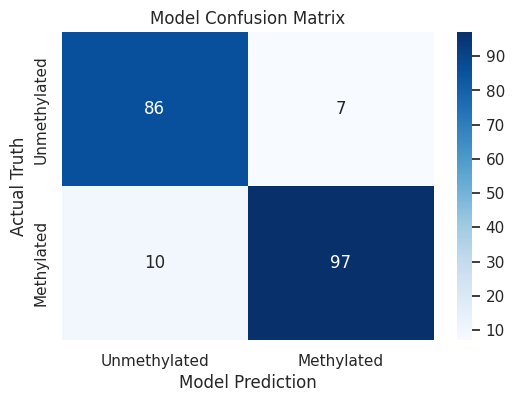

In [8]:
X = df.drop('methylation_status', axis=1)
y = df['methylation_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} sample, Testing on {len(X_test)} sample...\n")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unmethylated', 'Methylated'],
            yticklabels=['Unmethylated', 'Methylated'])
plt.title("Model Confusion Matrix")
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

In [9]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_12230/1592862700.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


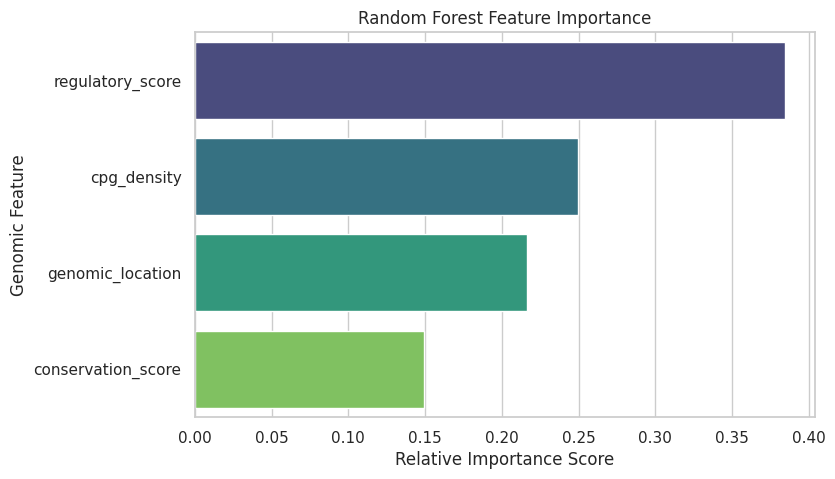

Exact Feature Importance Scores:
- regulatory_score: 0.3846
- cpg_density: 0.2496
- genomic_location: 0.2162
- conservation_score: 0.1496


In [10]:
importances = rf_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance Score')
plt.ylabel('Genomic Feature')
plt.show()

print("Exact Feature Importance Scores:")
for index, row in df_importance.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

# Cross Validation and Model Comparison with Hyperparameter Tuning

In [11]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

STAGE 1: 5-FOLD CROSS-VALIDATION (Stability Check)
Scores for each fold: [0.91875 0.93125 0.94375 0.93125 0.95   ]
Mean CV Accuracy: 93.50% (+/- 1.09%)
Interpretation: If the variance is low, the baseline 91.50% model is stable and reliable.

STAGE 2: MODEL COMPARISON BENCHMARK
- Logistic Regression (Linear): 97.00% test accuracy
- Random Forest (Tree Ensemble): 91.50% test accuracy
- Gradient Boosting (Sequential Tree): 89.50% test accuracy

STAGE 3: HYPERPARAMETER TUNING (Optimizing Random Forest)
Searching for the best mathematical combination of parameters...

Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Optimized Random Forest Test Accuracy: 90.50%


/tmp/ipykernel_12230/802228029.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_results, y=all_names, palette="viridis")


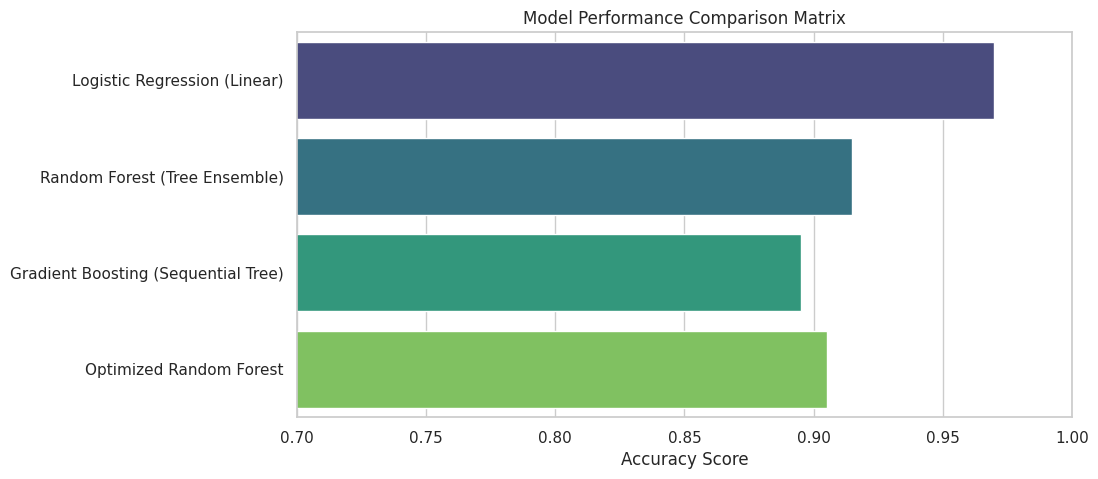

In [12]:
X = df.drop('methylation_status', axis=1)
y = df['methylation_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*60)
print("STAGE 1: 5-FOLD CROSS-VALIDATION (Stability Check)")
print("="*60)
# The baseline Random Forest across 5 different splits of the training data
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")
print("Interpretation: If the variance is low, the baseline 91.50% model is stable and reliable.\n")


print("="*60)
print("STAGE 2: MODEL COMPARISON BENCHMARK")
print("="*60)
models = {
    "Logistic Regression (Linear)": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest (Tree Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting (Sequential Tree)": GradientBoostingClassifier(random_state=42)
}

model_results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    preds = model.predict(X_test)
    # Score
    acc = accuracy_score(y_test, preds)
    model_results[name] = acc
    print(f"- {name}: {acc * 100:.2f}% test accuracy")


print("\n" + "="*60)
print("STAGE 3: HYPERPARAMETER TUNING (Optimizing Random Forest)")
print("="*60)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Searching for the best mathematical combination of parameters...")
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

tuned_preds = best_rf.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_preds)
print(f"Optimized Random Forest Test Accuracy: {tuned_acc * 100:.2f}%")

# Plot
plt.figure(figsize=(10, 5))
all_results = list(model_results.values()) + [tuned_acc]
all_names = list(model_results.keys()) + ["Optimized Random Forest"]

sns.barplot(x=all_results, y=all_names, palette="viridis")
plt.xlim(0.7, 1.0)
plt.title("Model Performance Comparison Matrix")
plt.xlabel("Accuracy Score")
plt.show()

In [13]:
import pickle
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

FINAL STAGE: EXTRACTING WINNING WEIGHTS & SAVING MODEL

Winning Logistic Regression Weights:
- cpg_density: +6.6153 (Increases methylation probability)
- regulatory_score: +6.4532 (Increases methylation probability)
- genomic_location: +5.4728 (Increases methylation probability)
- conservation_score: +4.5080 (Increases methylation probability)


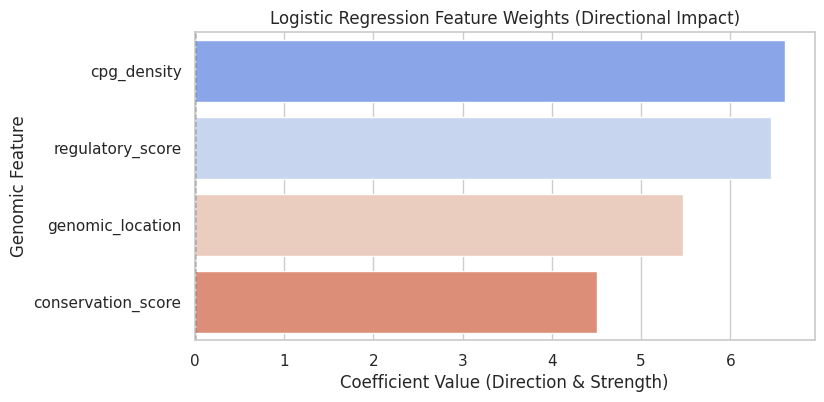

SUCCESS: Trained model saved to storage as 'retina_methylation_logistic_model.joblib'


In [14]:
print("="*60)
print("FINAL STAGE: EXTRACTING WINNING WEIGHTS & SAVING MODEL")
print("="*60)

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)

coefficients = final_model.coef_[0]
features = X.columns

df_weights = pd.DataFrame({
    'Feature': features,
    'Weight (Coefficient)': coefficients,
    'Absolute Impact': np.abs(coefficients)
}).sort_values(by='Absolute Impact', ascending=False)

print("\nWinning Logistic Regression Weights:")
for index, row in df_weights.iterrows():
    direction = "Increases" if row['Weight (Coefficient)'] > 0 else "Decreases"
    print(f"- {row['Feature']}: {row['Weight (Coefficient)']:+.4f} ({direction} methylation probability)")

plt.figure(figsize=(8, 4))
sns.barplot(data=df_weights, x='Weight (Coefficient)', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Logistic Regression Feature Weights (Directional Impact)")
plt.xlabel("Coefficient Value (Direction & Strength)")
plt.ylabel("Genomic Feature")
plt.show()

# Export model to a file
model_filename = 'retina_methylation_logistic_model.joblib'
joblib.dump(final_model, open(model_filename, 'wb'))

print("="*60)
print(f"SUCCESS: Trained model saved to storage as '{model_filename}'")
print("="*60)

In [15]:
import joblib
import numpy as np

loaded_model = joblib.load('retina_methylation_logistic_model.joblib')

new_scan_data = np.array([[0.85, 0.40, 0.75, 0.50]])
prediction = loaded_model.predict(new_scan_data)
probability = loaded_model.predict_proba(new_scan_data)[0][1] # Get confidence %

print("--- New Lab Scan Analysis ---")
if prediction[0] == 1:
    print(f"Diagnosis: METHYLATED")
    print(f"Model Confidence: {probability*100:.2f}%")
else:
    print(f"Diagnosis: UNMETHYLATED")
    print(f"Model Confidence: {(1-probability)*100:.2f}%")

--- New Lab Scan Analysis ---
Diagnosis: METHYLATED
Model Confidence: 77.75%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
